# GCN with content (article embeddings)

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm import tqdm
import time

import torch
from torch_geometric.data import Data, HeteroData
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch_geometric.nn import GCNConv

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.model_selection import train_test_split

from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
from torch.nn import Linear
from torch_geometric.nn.inits import glorot, zeros

In [4]:
import matplotlib as mpl

# Enable LaTeX-style font
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

## 01 Load Data
https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html

In [5]:
# Load data
train_data = pd.read_csv('../02_data/train_test/train_data.csv')
test_data = pd.read_csv('../02_data/train_test/test_data.csv')
edge_np = np.load("../02_data/train_test/validated_edges.npy", allow_pickle=True)

In [6]:
# Validated Projected Monopartite Network
edge_nodes = set(edge_np.flatten()) 

# Convert edge list numpy array to DataFrame
edge_list = pd.DataFrame(edge_np, columns=["source", "target"])

In [7]:
edge_list

,source,target
0,1270,5187
1,1270,5232
2,1270,5266
3,1270,5289
4,1270,5298
...,...,...
350878,147,3398
350879,147,6027
350880,147,390
350881,147,4372


In [8]:
print("edge_list info (train edges)")
print(edge_list.info())
print("-------------------------------------------------")

print("train_data info")
print(train_data.info())
print("-------------------------------------------------")

print("test_data info")
print(test_data.info())
print("-------------------------------------------------")

edge_list info (train edges)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350883 entries, 0 to 350882
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   source  350883 non-null  int64
 1   target  350883 non-null  int64
dtypes: int64(2)
memory usage: 5.4 MB
None
-------------------------------------------------
train_data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             4884 non-null   object 
 1   url_index          4884 non-null   object 
 2   article            4884 non-null   object 
 3   article_embedding  4884 non-null   object 
 4   virality           4884 non-null   float64
 5   avalanches         4884 non-null   float64
 6   messages           4884 non-null   float64
 7   chats              4884 non-null   float64
 8   pc1             

## 02 Preprocessing

In [9]:
def preprocess_embedding(emb):
    # If it's already a numpy array, return as is
    if isinstance(emb, np.ndarray):
        return emb

    # If it's a list or other iterable, convert it to a numpy array
    if isinstance(emb, (list, tuple)):
        return np.array(emb, dtype=np.float32)

    # If it's a string, clean and parse
    if isinstance(emb, str):
        try:
            # Fix missing commas using regex
            emb = re.sub(r'(?<=\d)\s+(?=\d|\-)', ',', emb)
            # Ensure it is wrapped in brackets
            if not emb.startswith("["):
                emb = "[" + emb
            if not emb.endswith("]"):
                emb = emb + "]"
            # Evaluate the cleaned string and convert to numpy array
            parsed_emb = eval(emb)  # Using eval since we sanitize the string
            return np.array(parsed_emb, dtype=np.float32)
        except Exception as e:
            raise ValueError(f"Failed to process embedding: {emb}. Error: {e}")

    # If none of the above, raise an error
    raise ValueError(f"Unsupported embedding format: {type(emb)}")


In [10]:
train_data['article_embedding'] = train_data['article_embedding'].apply(preprocess_embedding)

In [11]:
# edge_list only contains valid domain indices
valid_domain_indices = set(train_data['domain_id'])

edge_list_filtered = edge_list[
    edge_list['source'].isin(valid_domain_indices) & edge_list['target'].isin(valid_domain_indices)
]

# mapping from original domain indices to new contiguous indices
unique_nodes = sorted(valid_domain_indices)  
node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(unique_nodes)}

# Apply re-indexing to edge_list
edge_index_mapped = edge_list_filtered.replace(node_mapping).values
edge_index = torch.tensor(edge_index_mapped, dtype=torch.long).t().contiguous()

# Update node_features to match new indices
train_data = train_data[train_data['domain_id'].isin(valid_domain_indices)]
train_data = train_data.set_index('domain_id').reindex(unique_nodes).fillna(0)

In [12]:
train_data.describe()

desc = train_data.describe()
desc = desc.drop(columns=['pc1'])
desc = desc.round(2)
desc.loc['count'] = desc.loc['count'].round(0).astype(int)

latex_table = desc.to_latex(float_format="%.2f")
with open("table.tex", "w") as f:
    f.write(latex_table)


In [13]:
def preprocess_train_data(train_data):
    # Ensure 'article_embedding' is preprocessed
    embeddings = np.vstack(train_data['article_embedding'].values)

    # Extract other features and convert them to numpy arrays + normalise
    # other_features = train_data[['virality', 'avalanches', 'messages', 'chats']].to_numpy(dtype=np.float32)
    # other_features = (other_features - other_features.mean()) / other_features.std()

    # Combine article embeddings with the other features
    # combined_features = np.hstack((embeddings, other_features)) #embeddings, 

    # align indices
    #combined_features = combined_features.reindex(combined_features.index).fillna(0)

    # Convert to torch tensor
    return torch.tensor(embeddings, dtype=torch.float32) #combined_features.values


In [14]:
# Align indices and merge features
node_features = preprocess_train_data(train_data)
#node_features = torch.tensor(node_features.values, dtype=torch.float)

In [15]:
# Target labels
pc1_values = train_data['pc1']
labels = pd.cut(pc1_values, bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2])
labels = torch.tensor(labels.values, dtype=torch.long)

In [16]:
# Train-test split
train_mask, val_mask = train_test_split(np.arange(len(labels)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long) # bool?
val_mask = torch.tensor(val_mask, dtype=torch.long)

# train_mask = torch.tensor(train_data['domain_id'].isin(train_domains_set).values, dtype=torch.bool)
# val_mask = torch.tensor(train_data['domain_id'].isin(val_domains_set).values, dtype=torch.bool)
test_mask = torch.tensor(test_data['domain_id'].values, dtype=torch.bool)

## 03 Model

In [17]:
# Define GCN Model
class GCN_super_basic(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super(GCN_super_basic, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [18]:
class GCN_basic(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0):
        super(GCN_basic, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

In [19]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

In [20]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super(GAT, self).__init__()

        heads=4
        
        # First GAT layer (multi-head attention)
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        
        # Second GAT layer
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        
        # Output GAT layer (single head for classification)
        self.conv3 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)

        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)  # Exponential Linear Unit (ELU) for better convergence
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)  # Classification output


In [21]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super(GraphSAGE, self).__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)  

https://medium.com/stanford-cs224w/incorporating-edge-features-into-graph-neural-networks-for-country-gdp-predictions-1d4dea68337d

In [22]:
class GATEdgeAttr(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.3):
        super(GATEdgeAttr, self).__init__()
        
        # multi-head attention
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout, edge_dim=1)
        
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout, edge_dim=1)
        
        # single head for classification
        self.conv3 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)

        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = F.elu(x)  # Exponential Linear Unit 
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index, edge_attr=edge_attr)
        return F.log_softmax(x, dim=1)  # Classification output


In [23]:
model_names = {
    "Super basic GCN": GCN_super_basic,
    "Basic GCN": GCN_basic,
    "GCN": GCN,
    "GAT": GAT,
    "GraphSAGE": GraphSAGE
}

## 04 Training

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [25]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight('balanced', classes=[0, 1, 2], y=labels.cpu().numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [26]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

def train_model(model_class, model_name, in_channels, hidden_channels, out_channels, 
                node_features, edge_index, labels, train_mask, val_mask, 
                device, num_epochs=100, lr=0.005, weight_decay=1e-4, dropout=0.3):

    model = model_class(in_channels, hidden_channels, out_channels, dropout).to(device)

    # Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()  #weight=class_weights

    # Move data to device
    node_features, edge_index = node_features.to(device), edge_index.to(device)
    labels, train_mask, val_mask = labels.to(device), train_mask.to(device), val_mask.to(device)

    train_losses, val_losses = [], []
    start_time = time.time()
    
    # Training loop
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass 
        out = model(node_features, edge_index)
        loss = criterion(out[train_mask], labels[train_mask])
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(node_features, edge_index)
            val_loss = criterion(val_out[val_mask], labels[val_mask])

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    training_time = time.time() - start_time
    print(f"Model: {model_class.__name__}")
    print(f"Training Time: {training_time:.2f}s")

    # Plot Learning Curve
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f'Training - Validation Loss - {model_name}')
    #plt.savefig(f'../03_plots/content/train_val_{model_name}.png')
    plt.show()

    return model, train_losses, val_losses, training_time


Model: GCN_super_basic
Training Time: 0.70s


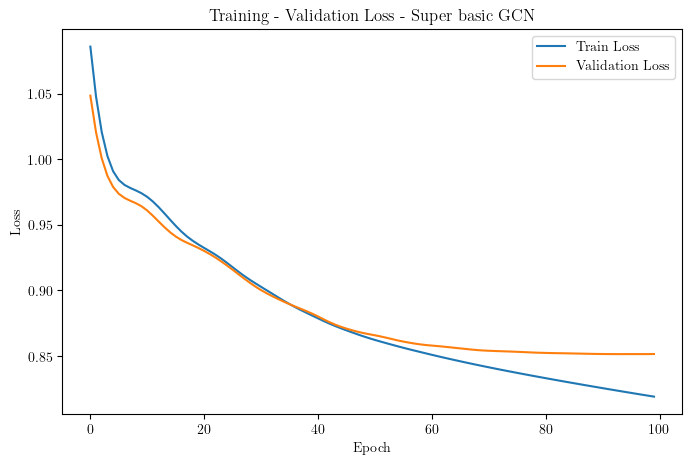

In [27]:
best_gcn_sb_model, train_losses, val_losses, training_time1 = train_model(
    model_class=GCN_super_basic,  
    model_name=list(model_names)[0],
    in_channels=node_features.shape[1],
    hidden_channels=64,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.001,
    weight_decay=1e-04,
    dropout=0.3
)

Model: GCN_basic
Training Time: 0.47s


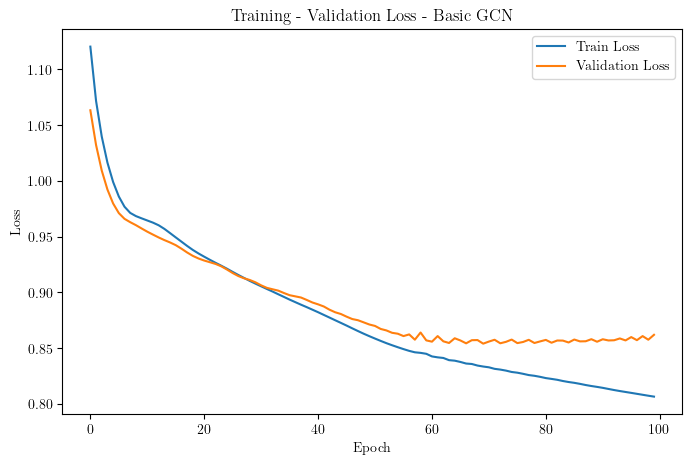

In [28]:
best_gcn_b_model, train_losses, val_losses, training_time2 = train_model(
    model_class=GCN_basic, 
    model_name=list(model_names)[1],
    in_channels=node_features.shape[1],
    hidden_channels=64,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.001,
    weight_decay=1e-4,
    dropout=0
)

Model: GCN
Training Time: 0.48s


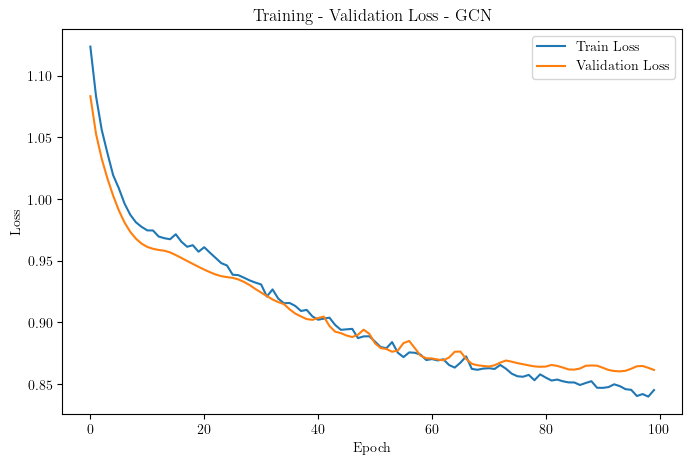

In [29]:
best_gcn_model, train_losses, val_losses, training_time3 = train_model(
    model_class=GCN,  
    model_name=list(model_names)[2],
    in_channels=node_features.shape[1],
    hidden_channels=64,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.001,
    weight_decay=1e-4,
    dropout=0.3
)

Model: GAT
Training Time: 2.13s


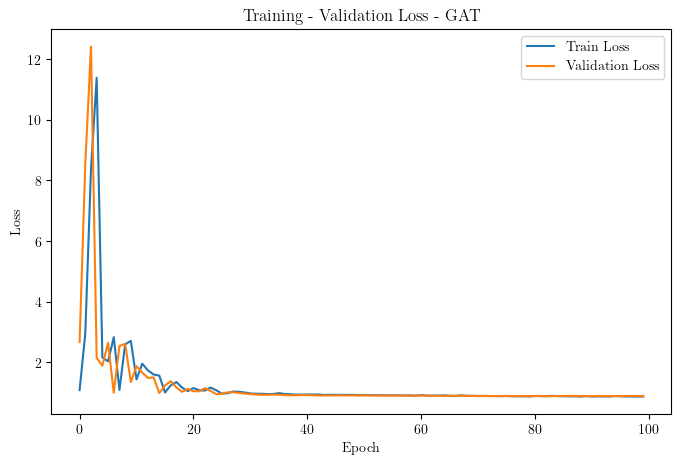

In [30]:
best_gat_model, train_losses, val_losses, training_time4 = train_model(
    model_class=GAT,  
    model_name=list(model_names)[3],
    in_channels=node_features.shape[1],
    hidden_channels=128,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.01,
    weight_decay=1e-3,
    dropout=0.3
)

Model: GraphSAGE
Training Time: 0.87s


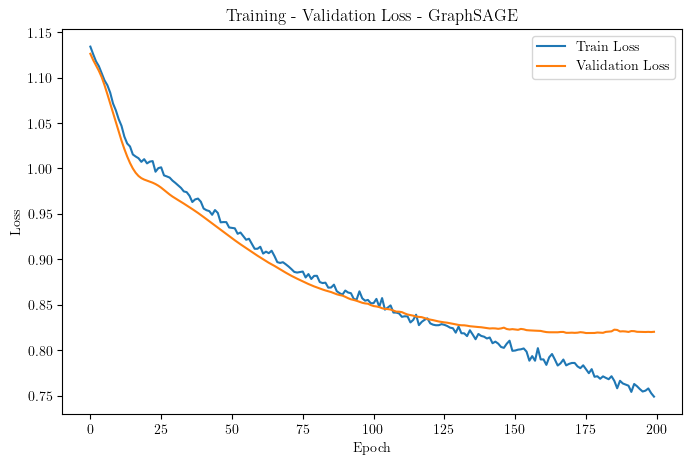

In [31]:
best_sage_model, train_losses, val_losses, training_time5 = train_model(
    model_class=GraphSAGE,
    model_name=list(model_names)[4],
    in_channels=node_features.shape[1],
    hidden_channels=32,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=200,
    lr=0.001,
    weight_decay=1e-4,
    dropout=0.5
)

In [32]:
training_times = [
    {"Model": list(model_names)[0], "Training Time (seconds)": training_time1},
    {"Model": list(model_names)[1], "Training Time (seconds)": training_time2},
    {"Model": list(model_names)[2], "Training Time (seconds)": training_time3},
    {"Model": list(model_names)[3], "Training Time (seconds)": training_time4},
    {"Model": list(model_names)[4], "Training Time (seconds)": training_time5}
]

# Convert to DataFrame
training_times_df = pd.DataFrame(training_times)

# Save to CSV
training_times_df.to_csv('../03_plots/content/training_times.csv', index=False)

## 05 Hyperparameter Tuning

In [33]:
from sklearn.model_selection import ParameterGrid
from torch.optim import Adam

param_grid = {
    "hidden_size": [32, 64, 128],
    "dropout": [0, 0.3, 0.5],
    "learning_rate": [0.01, 0.005, 0.001],
    "weight_decay": [1e-5, 1e-4, 1e-3]
}

# Get all parameter combinations
param_grid = list(ParameterGrid(param_grid))

In [34]:
def train_and_tune_model(model_class, param_grid, node_features, edge_index, labels,
                         train_mask, val_mask, device, class_weights,
                         latex_results_dict, edge_attr=None):
    best_model = None
    best_params = None
    best_val_loss = float("inf")

    node_features = node_features.to(device)
    edge_index = edge_index.to(device)
    labels = labels.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)

    model_name = model_class.__name__
    
    for params in param_grid:
        train_losses, val_losses = [], []

        model = model_class(
            in_channels=node_features.shape[1], 
            hidden_channels=params["hidden_size"], 
            out_channels=3, 
            dropout=params["dropout"]
        ).to(device)

        optimizer = Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
        criterion = torch.nn.CrossEntropyLoss()  # weight=class_weights

        num_epochs = 100
        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()
            out = model(node_features, edge_index)
            loss = criterion(out[train_mask], labels[train_mask])
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

            model.eval()
            with torch.no_grad():
                val_out = model(node_features, edge_index)
                val_loss = criterion(val_out[val_mask], labels[val_mask])
            val_losses.append(val_loss.item())

        if val_loss < best_val_loss:
            best_val_loss = val_loss.item()
            best_train_losses = train_losses
            best_val_losses = val_losses
            best_model = model
            best_params = params

            torch.save(best_model.state_dict(), f'../03_plots/content/best_{model_name}.pth')

    # Plot Learning Curve
    plt.figure(figsize=(8, 5))
    plt.plot(best_train_losses, label="Train Loss")
    plt.plot(best_val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f'Training - Validation Loss - {model_name}')
    plt.savefig(f'../03_plots/content/train_val_{model_name}.png')
    plt.show()

    print("Best Hyperparameters:", best_params)
    print("Best Validation Loss:", best_val_loss)

    # Append results to shared LaTeX dictionary
    best_params_with_loss = best_params.copy()
    best_params_with_loss["val_loss"] = round(best_val_loss, 4)
    latex_results_dict[model_name] = best_params_with_loss

    return best_model, best_params, best_val_loss

In [35]:
def export_latex_table(latex_results_dict, filename='best_hyperparameters_content.tex'):
    # Collect all unique hyperparameter names across models
    all_keys = set()
    for params in latex_results_dict.values():
        all_keys.update(params.keys())
    all_keys = sorted(all_keys)

    # Start LaTeX table
    latex = "\\begin{table}[h!]\n\\centering\n"
    latex += "\\caption{Best Hyperparameters for All Models}\n"
    latex += "\\begin{tabular}{l" + " c" * len(all_keys) + "}\n"
    latex += "\\toprule\n"
    latex += "Model & " + " & ".join(all_keys) + " \\\\\n"
    latex += "\\midrule\n"

    for model, params in latex_results_dict.items():
        row = [model] + [str(params.get(key, "-")) for key in all_keys]
        latex += " & ".join(row) + " \\\\\n"

    latex += "\\bottomrule\n"
    latex += "\\end{tabular}\n"
    latex += "\\end{table}\n"

    with open(f'../03_plots/content/{filename}', 'w') as f:
        f.write(latex)


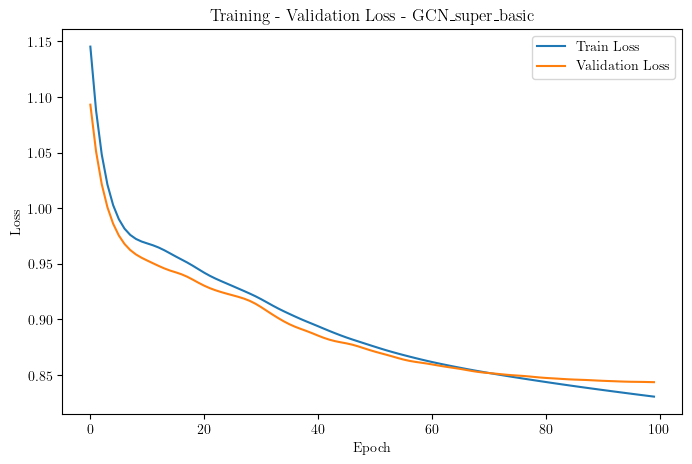

Best Hyperparameters: {'dropout': 0, 'hidden_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.0001}
Best Validation Loss: 0.8436101078987122


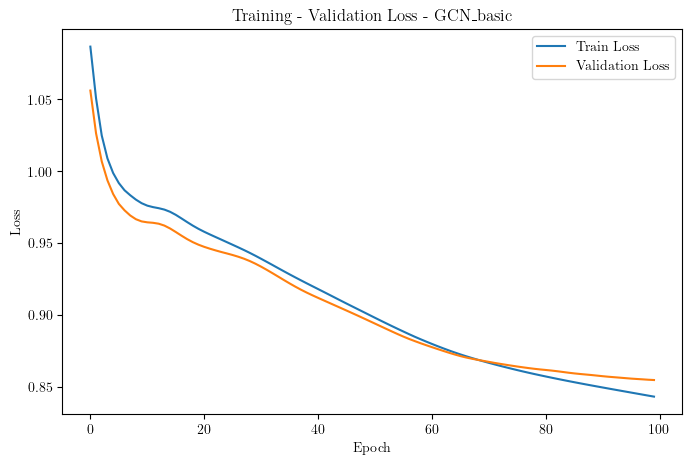

Best Hyperparameters: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.001, 'weight_decay': 0.001}
Best Validation Loss: 0.854523777961731


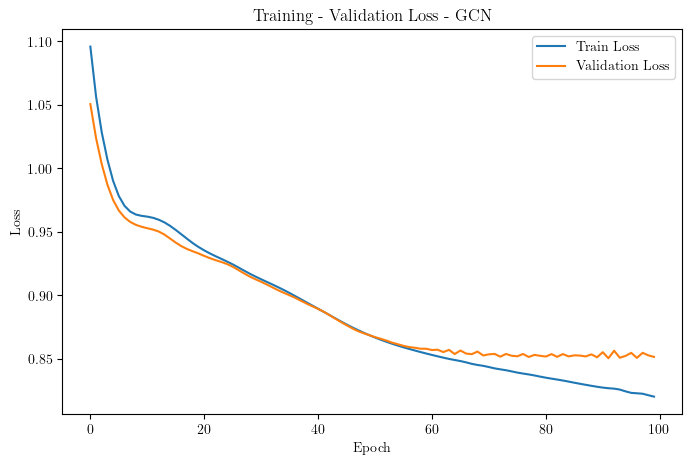

Best Hyperparameters: {'dropout': 0, 'hidden_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001}
Best Validation Loss: 0.8513238430023193


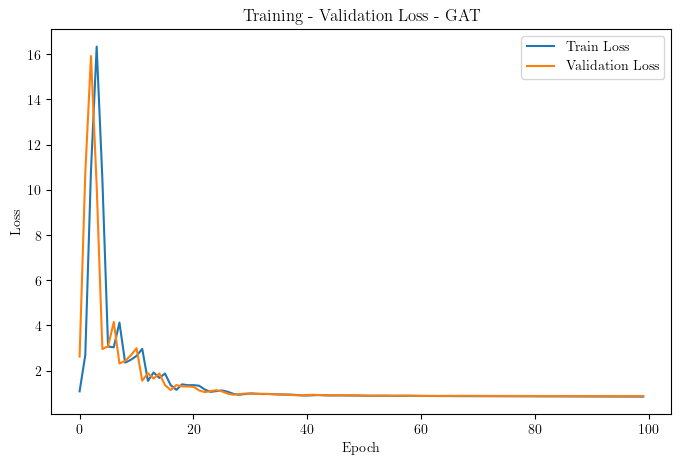

Best Hyperparameters: {'dropout': 0, 'hidden_size': 128, 'learning_rate': 0.01, 'weight_decay': 0.001}
Best Validation Loss: 0.8759139776229858


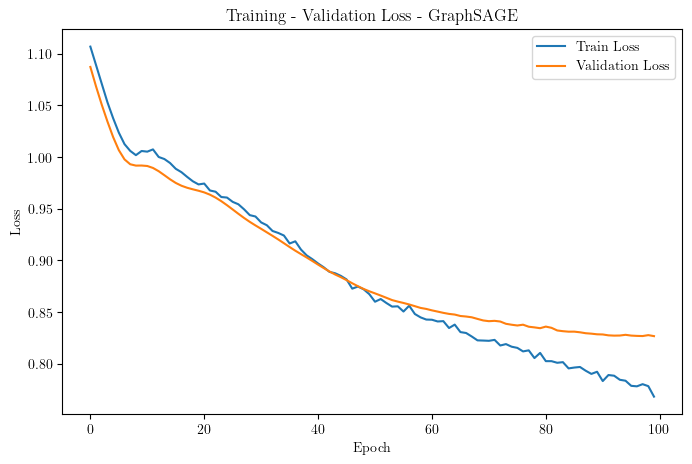

Best Hyperparameters: {'dropout': 0.3, 'hidden_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001}
Best Validation Loss: 0.8267290592193604


In [36]:
latex_results = {}

for model_class in [GCN_super_basic, GCN_basic, GCN, GAT, GraphSAGE]:
    train_and_tune_model(
        model_class, param_grid, node_features, edge_index, labels,
        train_mask, val_mask, device, class_weights,
        latex_results
    )

# Export the combined LaTeX table
export_latex_table(latex_results)


## 06 Evaluation

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import os

def evaluate_models(models, node_features, edge_index, labels, mask, device, split_name="val", save_dir="../03_plots"):
    results = []

    node_features, edge_index = node_features.to(device), edge_index.to(device)
    labels, mask = labels.to(device), mask.to(device)

    # Ensure save directory exists
    plot_path = os.path.join(save_dir, split_name)
    os.makedirs(plot_path, exist_ok=True)

    for model_name, model in models.items():
        model.eval()
        with torch.no_grad():
            out = model(node_features, edge_index)
            pred = out.argmax(dim=1)

        y_true = labels[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()

        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")

        print(f"Model: {model_name}")
        print(f"{split_name.capitalize()} Accuracy: {accuracy:.4f}")
        print(f"{split_name.capitalize()} F1-Score: {f1:.4f}")
        print("\nClassification Report:\n", classification_report(y_true, y_pred))

        conf_matrix = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(conf_matrix)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix - {model_name} (with content)")
        plt.savefig(os.path.join(plot_path, f"con_matrix_{model_name}.png"))
        plt.show()

        results.append({
            "Model": model_name,
            f"{split_name.capitalize()} Accuracy": accuracy,
            f"{split_name.capitalize()} F1-Score": f1
        })

    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join(plot_path, f"results_{split_name}.csv"), index=False)

    return results_df


Model: Super basic GCN
Val Accuracy: 0.5629
Val F1-Score: 0.5608

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.40      0.45       141
           1       0.52      0.54      0.53       420
           2       0.62      0.64      0.63       416

    accuracy                           0.56       977
   macro avg       0.55      0.53      0.54       977
weighted avg       0.56      0.56      0.56       977



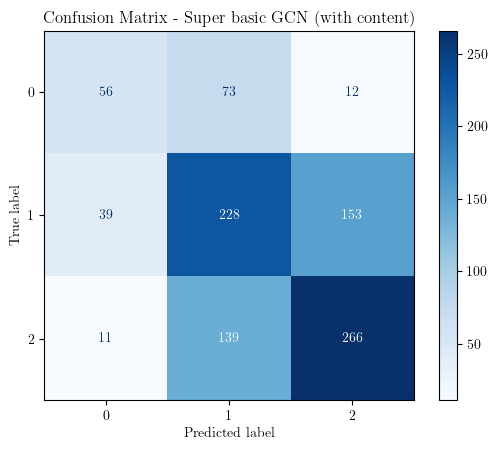

Model: Basic GCN
Val Accuracy: 0.5599
Val F1-Score: 0.5594

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.43      0.47       141
           1       0.52      0.56      0.54       420
           2       0.62      0.61      0.61       416

    accuracy                           0.56       977
   macro avg       0.55      0.53      0.54       977
weighted avg       0.56      0.56      0.56       977



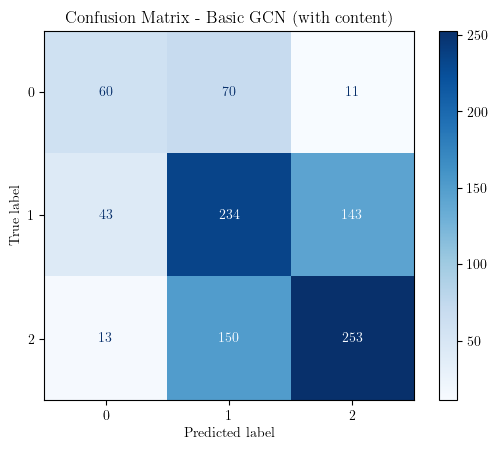

Model: GCN
Val Accuracy: 0.5466
Val F1-Score: 0.5438

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.40      0.44       141
           1       0.51      0.50      0.50       420
           2       0.60      0.64      0.62       416

    accuracy                           0.55       977
   macro avg       0.53      0.51      0.52       977
weighted avg       0.54      0.55      0.54       977



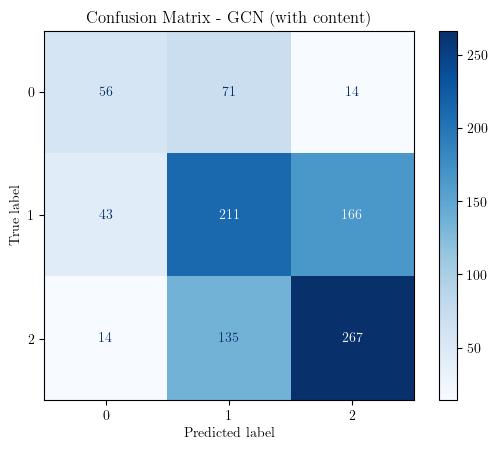

Model: GAT
Val Accuracy: 0.5394
Val F1-Score: 0.5326

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.26      0.35       141
           1       0.48      0.58      0.53       420
           2       0.60      0.60      0.60       416

    accuracy                           0.54       977
   macro avg       0.55      0.48      0.49       977
weighted avg       0.55      0.54      0.53       977



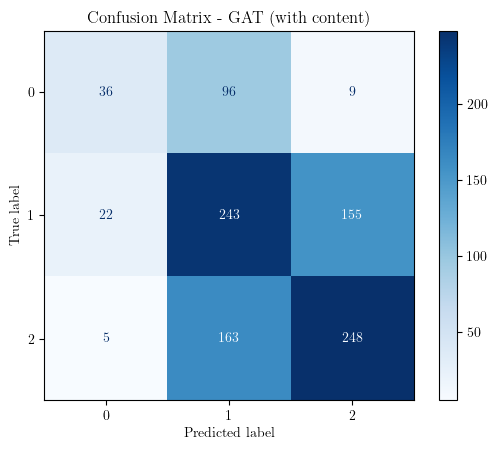

Model: GraphSAGE
Val Accuracy: 0.5691
Val F1-Score: 0.5649

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.41      0.47       141
           1       0.52      0.50      0.51       420
           2       0.62      0.69      0.65       416

    accuracy                           0.57       977
   macro avg       0.56      0.53      0.54       977
weighted avg       0.57      0.57      0.56       977



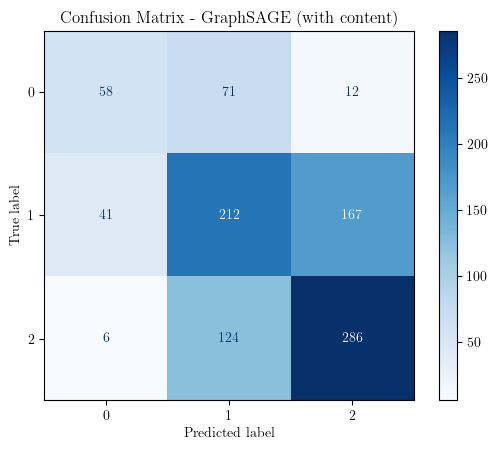

In [39]:
# Define models to evaluate
models_to_compare = {
    "Super basic GCN": best_gcn_sb_model,
    "Basic GCN": best_gcn_b_model,
    "GCN": best_gcn_model,
    "GAT": best_gat_model,
    "GraphSAGE": best_sage_model
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Run evaluation on all models
evaluation_results = evaluate_models(
    models=models_to_compare, 
    node_features=node_features, 
    edge_index=edge_index, 
    labels=labels, 
    mask=val_mask, 
    device=device,
    split_name="val"
)


## 07 Testing

In [40]:
# test labels
pc1_values = test_data['pc1']
test_labels = pd.cut(pc1_values, bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2])
test_labels = torch.tensor(test_labels.values, dtype=torch.long)

In [41]:
test_data.describe()

,virality,avalanches,messages,chats,pc1,domain_id
count,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000
mean,0.854757,3.748973,7.343010,2.557141,0.599300,2976.165303
std,0.136008,9.309147,41.242178,5.026573,0.198432,1797.169161
min,0.188982,1.000000,1.000000,1.000000,0.044752,8.000000
25%,0.812323,1.333333,1.500000,1.142857,0.489881,1406.250000
50%,0.884464,2.000000,2.365818,1.532609,0.630153,2892.000000
75%,0.940080,3.180223,4.090336,2.165975,0.740966,4531.750000
max,1.000000,157.000000,1073.000000,126.613614,0.971184,6104.000000


In [42]:
# Safe fallback if domain_id isn't correct
test_indices = test_data.index.to_numpy()

# Make sure all test indices are valid
assert test_indices.max() < labels.shape[0], "Test indices exceed label size"

test_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
test_mask[test_indices] = True


In [43]:
print(test_indices.max())

1221


In [44]:
test_indices = test_data['domain_id'].to_numpy()
#test_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
#test_mask[test_indices] = True

test_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
test_mask[test_data.index.to_numpy()] = True

In [47]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

def test_models_on_test_set(models, node_features, edge_index, labels, test_mask, device):
    results = []

    node_features, edge_index = node_features.to(device), edge_index.to(device)
    labels, test_mask = labels.to(device), test_mask.to(device)

    for model_name, model in models.items():
        model.eval()
        with torch.no_grad():
            out = model(node_features, edge_index)
            pred = out.argmax(dim=1)

        y_true = labels[test_mask].cpu().numpy()
        y_pred = pred[test_mask].cpu().numpy()

        # Compute metrics
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        class_report = classification_report(y_true, y_pred, output_dict=True)

        precision = class_report['weighted avg']['precision']
        recall = class_report['weighted avg']['recall']
        
        print(f"Model: {model_name}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print("\nClassification Report:\n", classification_report(y_true, y_pred))

        # Confusion Matrix
        conf_matrix = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(conf_matrix)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix - {model_name} (content)")
        plt.savefig(f'../03_plots/content/con_matrix_{model_name}.png')
        plt.show()

        # Store metrics
        results.append({
            "Model": model_name,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4)
        })

        # Save classification report
        with open(f'../03_plots/content/classification_report_{model_name}.txt', 'w') as f:
            f.write(classification_report(y_true, y_pred))

    results_df = pd.DataFrame(results)
    results_df.to_csv('../03_plots/content/results_test.csv', index=False)

    # Export LaTeX table
    latex_table = results_df.to_latex(index=False,
                                      float_format="%.4f",
                                      caption="Evaluation Metrics on Test Set (with content)",
                                      label="tab:test_results_content",
                                      column_format="lcccc",
                                      bold_rows=False,
                                      longtable=False,
                                      escape=False)
    latex_table = latex_table.replace("\\toprule", "\\toprule").replace("\\midrule", "\\midrule").replace("\\bottomrule", "\\bottomrule")

    with open('../03_plots/content/results_test.tex', 'w') as f:
        f.write(latex_table)

    return results_df


Model: Super basic GCN
Accuracy: 0.5851
F1-Score: 0.5830

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.43      0.47       195
           1       0.55      0.57      0.56       533
           2       0.64      0.66      0.65       494

    accuracy                           0.59      1222
   macro avg       0.57      0.55      0.56      1222
weighted avg       0.58      0.59      0.58      1222



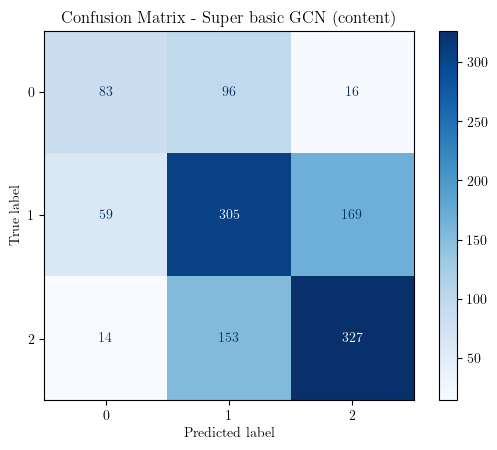

Model: Basic GCN
Accuracy: 0.5843
F1-Score: 0.5840

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.48      0.51       195
           1       0.55      0.58      0.56       533
           2       0.64      0.63      0.64       494

    accuracy                           0.58      1222
   macro avg       0.58      0.56      0.57      1222
weighted avg       0.58      0.58      0.58      1222



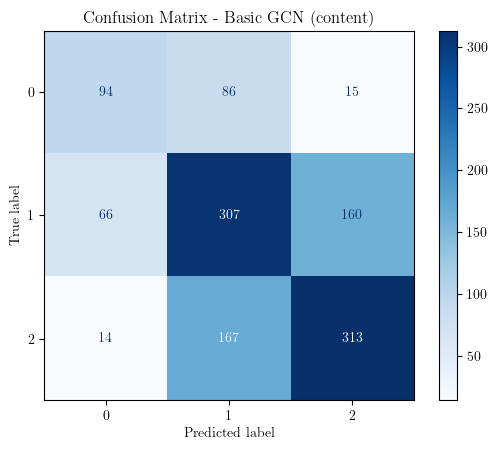

Model: GCN
Accuracy: 0.5728
F1-Score: 0.5706

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.45      0.47       195
           1       0.55      0.53      0.54       533
           2       0.62      0.67      0.65       494

    accuracy                           0.57      1222
   macro avg       0.55      0.55      0.55      1222
weighted avg       0.57      0.57      0.57      1222



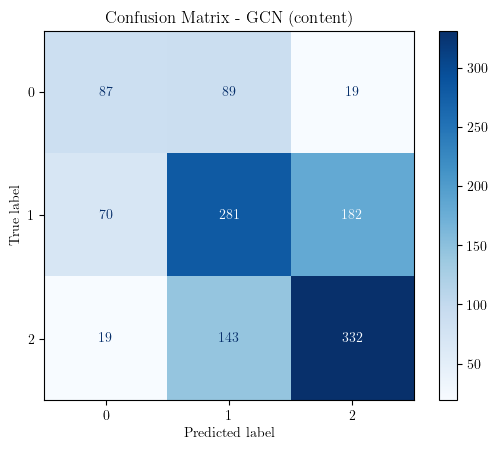

Model: GAT
Accuracy: 0.5696
F1-Score: 0.5637

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.31      0.41       195
           1       0.52      0.63      0.57       533
           2       0.62      0.61      0.62       494

    accuracy                           0.57      1222
   macro avg       0.59      0.52      0.53      1222
weighted avg       0.58      0.57      0.56      1222



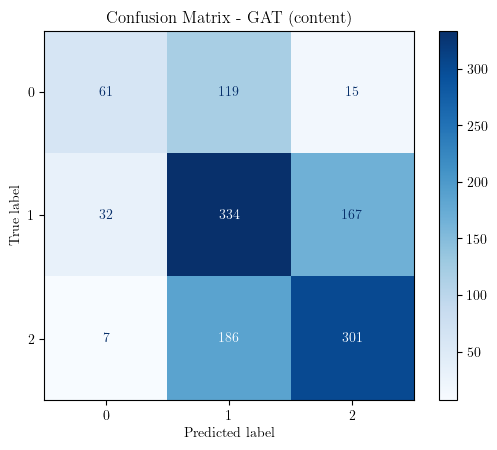

Model: GraphSAGE
Accuracy: 0.6293
F1-Score: 0.6262

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.52      0.58       195
           1       0.60      0.57      0.59       533
           2       0.65      0.74      0.69       494

    accuracy                           0.63      1222
   macro avg       0.63      0.61      0.62      1222
weighted avg       0.63      0.63      0.63      1222



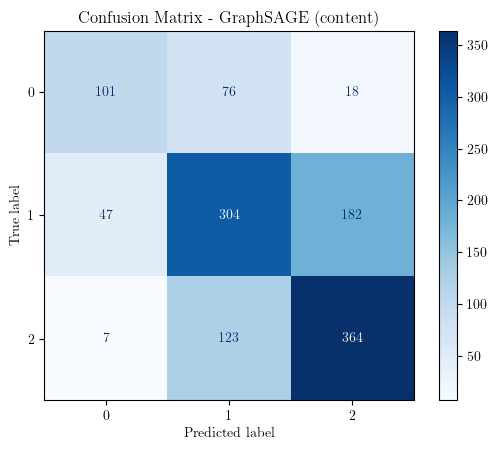

In [48]:
test_results = test_models_on_test_set(
    models=models_to_compare,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    test_mask=test_mask,  # Define this accordingly
    device=device
)
